|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 0:</h2>|<h1>From a Program to a Model<h1>|
|<h2>Section:</h2>|<h1>Attention<h1>|
|<h2>Lecture:</h2>|<h1><b>Heads, and the cache<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
from transformers import AutoConfig
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

def softmax(scores, axis=-1):
  exponentials = np.exp(scores - scores.max(axis=axis, keepdims=True))
  return exponentials / exponentials.sum(axis=axis, keepdims=True)

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Heads, and the cache that makes decode cheap

The last notebook built one lookup. A real layer runs many lookups side by
side. Then this notebook finds a fact about the keys and the values: they
never change after the model computes them. That fact gives the **KV cache**,
the data structure that the rest of this course is about.

### Step 1: many lookups side by side

Divide the query, key and value vectors into pieces. Each piece does its own
lookup. One lookup is an **attention head**. Different heads learn to look for
different things. The outputs of all heads then join into one vector again.

`head_dim` is the length of the vector of one head.

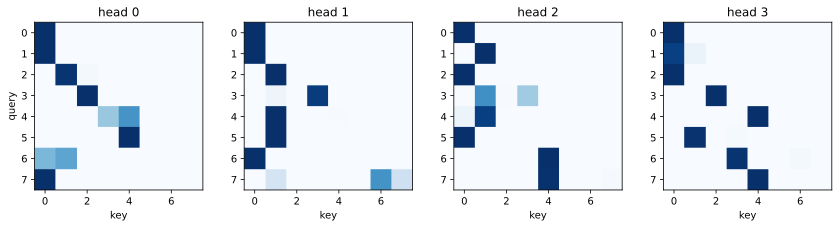

In [2]:
NUM_TOKENS, HIDDEN, NUM_HEADS = 8, 16, 4
HEAD_DIM = HIDDEN // NUM_HEADS
hidden_states = rng.normal(size=(NUM_TOKENS, HIDDEN))
query_weight, key_weight, value_weight = (rng.normal(size=(HIDDEN, HIDDEN)) for _ in range(3))

def split_heads(vectors, num_heads):
  """(tokens, num_heads * HEAD_DIM) -> (num_heads, tokens, HEAD_DIM)"""
  return vectors.reshape(len(vectors), num_heads, HEAD_DIM).transpose(1, 0, 2)

def causal_weights(queries, keys):
  """The lookup weights of each head: (heads, tokens, tokens)."""
  scores = queries @ keys.transpose(0, 2, 1) / np.sqrt(HEAD_DIM)
  scores[:, np.triu(np.ones((len(queries[0]),) * 2, dtype=bool), k=1)] = -np.inf
  return softmax(scores)

queries = split_heads(hidden_states @ query_weight, NUM_HEADS)
keys = split_heads(hidden_states @ key_weight, NUM_HEADS)
weights = causal_weights(queries, keys)

fig, axes = plt.subplots(1, NUM_HEADS, figsize=(12, 3))
for head, axis in enumerate(axes):
  axis.imshow(weights[head], cmap='Blues')
  axis.set(title=f'head {head}', xlabel='key', ylabel='query' if head == 0 else '')
plt.tight_layout()
plt.show()

### Step 2: heads that share keys and values

Many current models use **grouped-query attention**, GQA. Several query heads
share one key head and one value head. The model then stores fewer keys and
values. Qwen3-0.6B has 16 query heads and 8 key-value heads: each pair of query
heads shares one.

In [3]:
config = AutoConfig.from_pretrained('Qwen/Qwen3-0.6B')
group = config.num_attention_heads // config.num_key_value_heads
print(f'query heads:     {config.num_attention_heads}')
print(f'key-value heads: {config.num_key_value_heads}')
print(f'query heads that share one key head: {group}')
print(f'keys and values to store: 1/{group} of one for each query head')

query heads:     16
key-value heads: 8
query heads that share one key head: 2
keys and values to store: 1/2 of one for each query head


### Step 3: the fact that makes decode cheap

The model generates one token at a time. At each step the text is one token
longer, and the loop of the last section runs the model on ALL the text again.

But look at the causal mask. The hidden state of token *i* depends only on
tokens 0 to *i*. So a later token cannot change it. So the key and the value of
token *i* are the same at each step, in each layer.

Check it on a model with two layers. Compute the keys of the second layer for
6 tokens, and then for 7 tokens.

In [4]:
layer_weights = [[rng.normal(size=(HIDDEN, HIDDEN)) / np.sqrt(HIDDEN) for _ in range(3)]
                 for _ in range(2)]

def keys_of_each_layer(hidden_states):
  """Run two causal attention layers. -> the keys that each layer made."""
  all_keys = []
  for query_weight, key_weight, value_weight in layer_weights:
    queries, keys, values = (hidden_states @ weight for weight in (query_weight, key_weight, value_weight))
    all_keys.append(keys)
    scores = queries @ keys.T / np.sqrt(HIDDEN)
    scores[np.triu(np.ones_like(scores, dtype=bool), k=1)] = -np.inf
    hidden_states = hidden_states + softmax(scores) @ values
  return all_keys

text = rng.normal(size=(7, HIDDEN))
keys_for_6 = keys_of_each_layer(text[:6])
keys_for_7 = keys_of_each_layer(text)
for layer in range(2):
  same = np.allclose(keys_for_6[layer], keys_for_7[layer][:6])
  print(f'layer {layer}: the keys of the first 6 tokens did not change: {same}')

layer 0: the keys of the first 6 tokens did not change: True
layer 1: the keys of the first 6 tokens did not change: True


So there is no reason to compute them again. Keep the keys and the values of
all earlier tokens in memory. At each step, compute the query, key and value
of the NEW token only. Append its key and value to the store. Then do its
lookup over all the stored keys and values.

That store is the **KV cache**. In software terms it is memoization.

With a cache, the first call processes the prompt and fills the cache: that is
the prefill. Each decode call then processes ONE token. Count the tokens that
the model processes, with and without the cache.

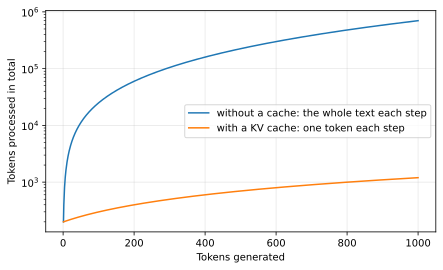

at 1,000 new tokens the cache saves 583x the work


In [5]:
PROMPT_TOKENS = 200
new_tokens = np.arange(1, 1001)
without_cache = np.cumsum(PROMPT_TOKENS + new_tokens - 1)    # the full text, at each step
with_cache = PROMPT_TOKENS + (new_tokens - 1)                # the prompt once, then 1 for each step

plt.figure(figsize=(7, 4))
plt.plot(new_tokens, without_cache, label='without a cache: the whole text each step')
plt.plot(new_tokens, with_cache, label='with a KV cache: one token each step')
plt.yscale('log')
plt.xlabel('Tokens generated')
plt.ylabel('Tokens processed in total')
plt.legend()
plt.grid(alpha=.3)
plt.show()
print(f'at 1,000 new tokens the cache saves {without_cache[-1] / with_cache[-1]:.0f}x the work')

### Step 4: the price is memory

The cache is not free. For each token, each layer stores one key and one value
for each key-value head. Count the bytes for Qwen3-0.6B in bf16, 2 bytes for
each number.

In [6]:
BYTES_PER_NUMBER = 2      # bf16
kv_bytes_per_token = (2 * config.num_hidden_layers * config.num_key_value_heads
                      * config.head_dim * BYTES_PER_NUMBER)     # 2: one key and one value
weight_bytes = 0.6e9 * BYTES_PER_NUMBER
print(f'KV cache for each token: {kv_bytes_per_token / 1024:.0f} KiB')
for context in (1_000, 4_000, 32_000):
  sequence_bytes = context * kv_bytes_per_token
  print(f'one sequence of {context:>6,} tokens: {sequence_bytes / 2**20:7.0f} MiB '
        f'= {100 * sequence_bytes / weight_bytes:4.0f}% of the size of the weights')

KV cache for each token: 112 KiB
one sequence of  1,000 tokens:     109 MiB =   10% of the size of the weights
one sequence of  4,000 tokens:     438 MiB =   38% of the size of the weights
one sequence of 32,000 tokens:    3500 MiB =  306% of the size of the weights


At 32,000 tokens, ONE conversation needs more memory than the whole model.
A server has many conversations at the same time.

### What to remember from this notebook

- A layer runs many **attention heads** side by side. With **GQA**, several
  query heads share one key head and one value head.
- The keys and values of a token never change after the model computes them.
- The **KV cache** stores them. Each decode step then processes one token, not
  the whole text.
- The cache costs memory for each token, and it grows with the context and the
  number of users.

Part 1 measures both halves of this trade: the time that the cache saves, and
the memory that it costs. Parts 2 to 4 are about how to fit the most users in
that memory.